# IMPORTS & SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

## Part 1: Data Loading & Basic Overview
First, we load the dataset and look at the raw tabular data, its structure, and standard statistical summaries to check for missing values or obvious anomalies.

In [2]:
# Load dataset
df = pd.read_csv('heart_disease.csv')

# EDA
initial_shape = df.shape
df = df.drop_duplicates()
print(f"Data Cleaning: Dropped duplicates. Shape changed from {initial_shape} to {df.shape}\n")

print("--- First 5 Rows of the Pristine Dataset ---")
display(df.head())

print("\n--- Dataset Information ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe().T)

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

Data Cleaning: Dropped duplicates. Shape changed from (1025, 14) to (302, 14)

--- First 5 Rows of the Pristine Dataset ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Dataset Information ---
<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2



--- Missing Values Count ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## PART 2 & 3 - EDA VISUALIZATIONS (Univariate & Bivariate)

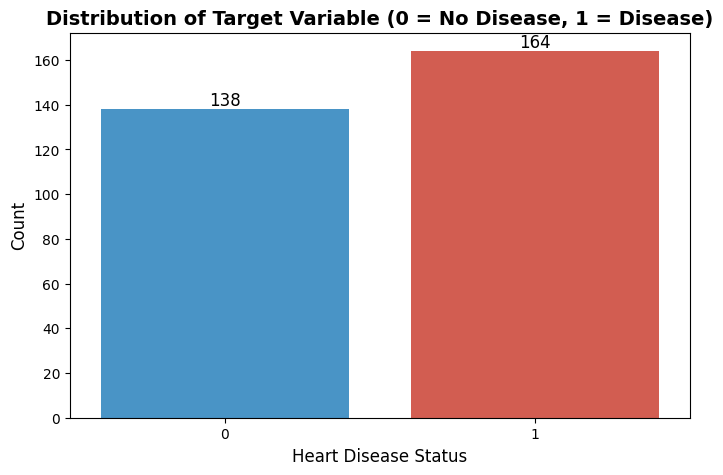

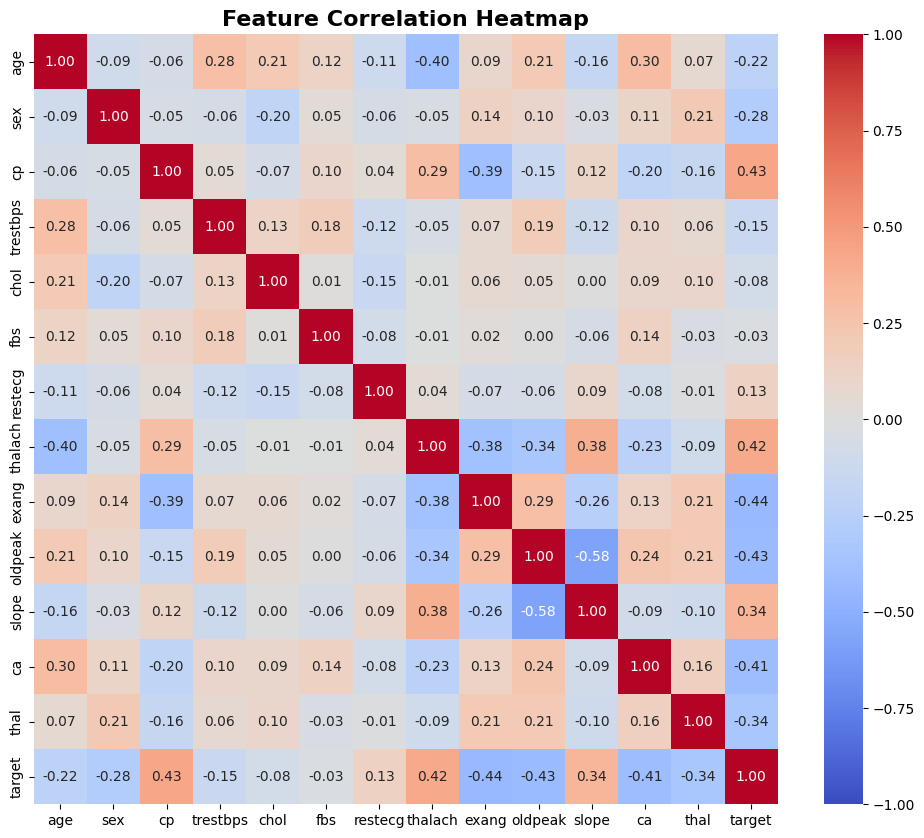

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='target', palette=['#3498db', '#e74c3c'])
plt.title('Distribution of Target Variable (0 = No Disease, 1 = Disease)', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

# Feature Correlation Heatmap (Crucial for baseline understanding)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

## Univariate & Bivariate Analysis
Visualizing continuous and categorical features, and how they relate to the target variable.

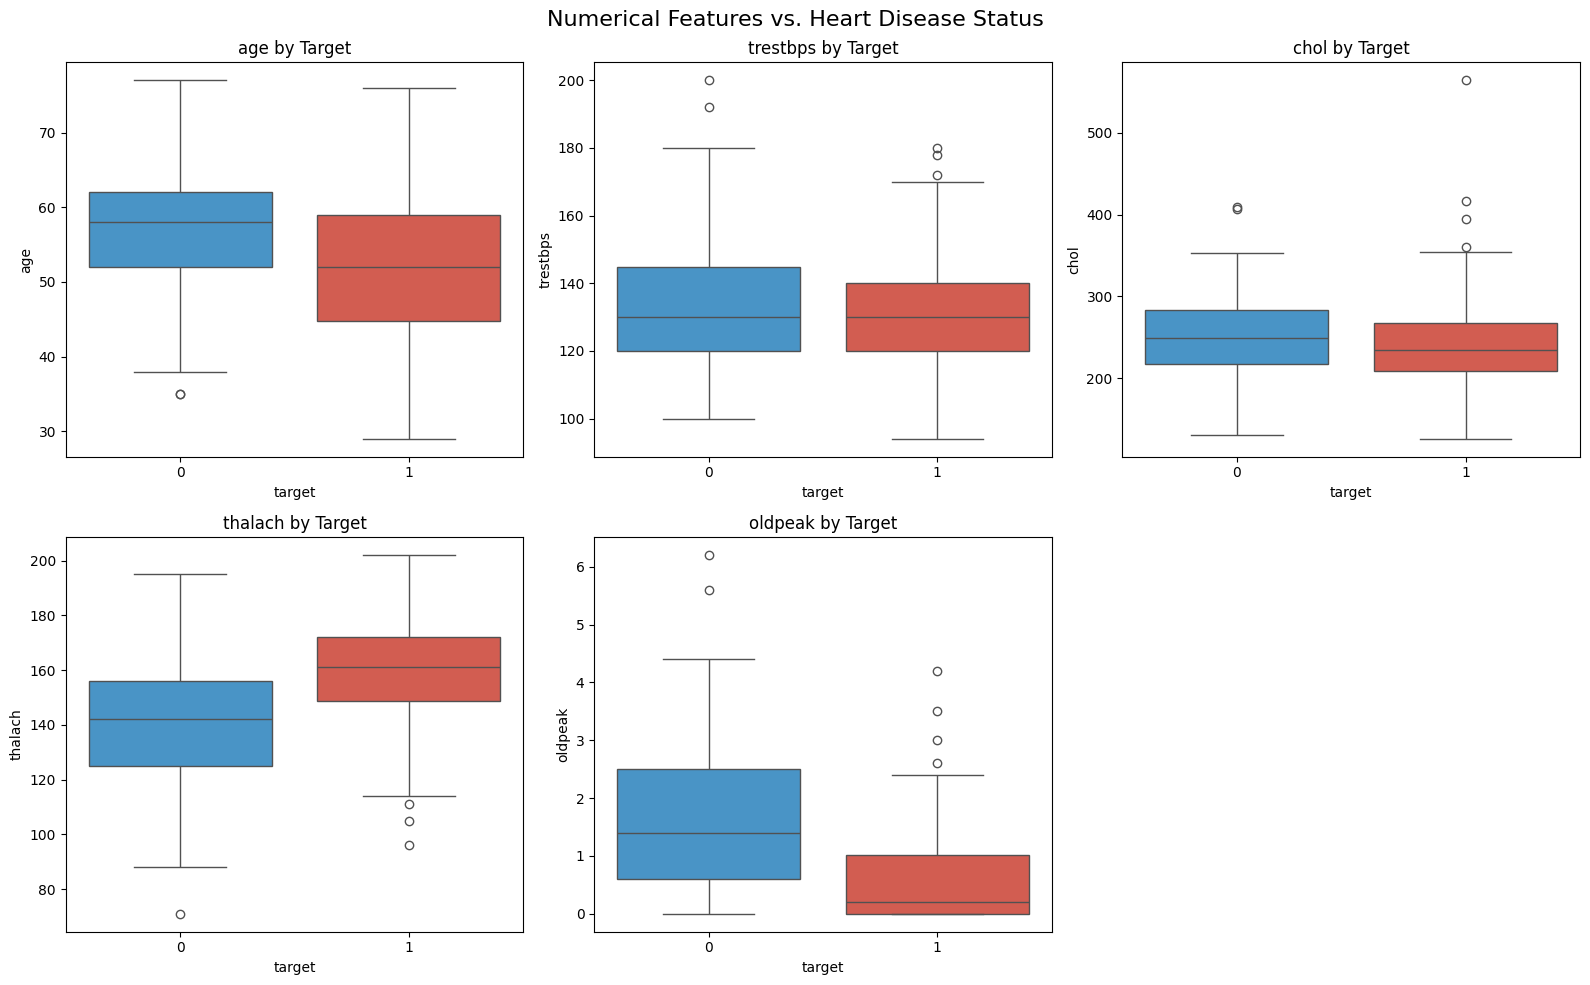

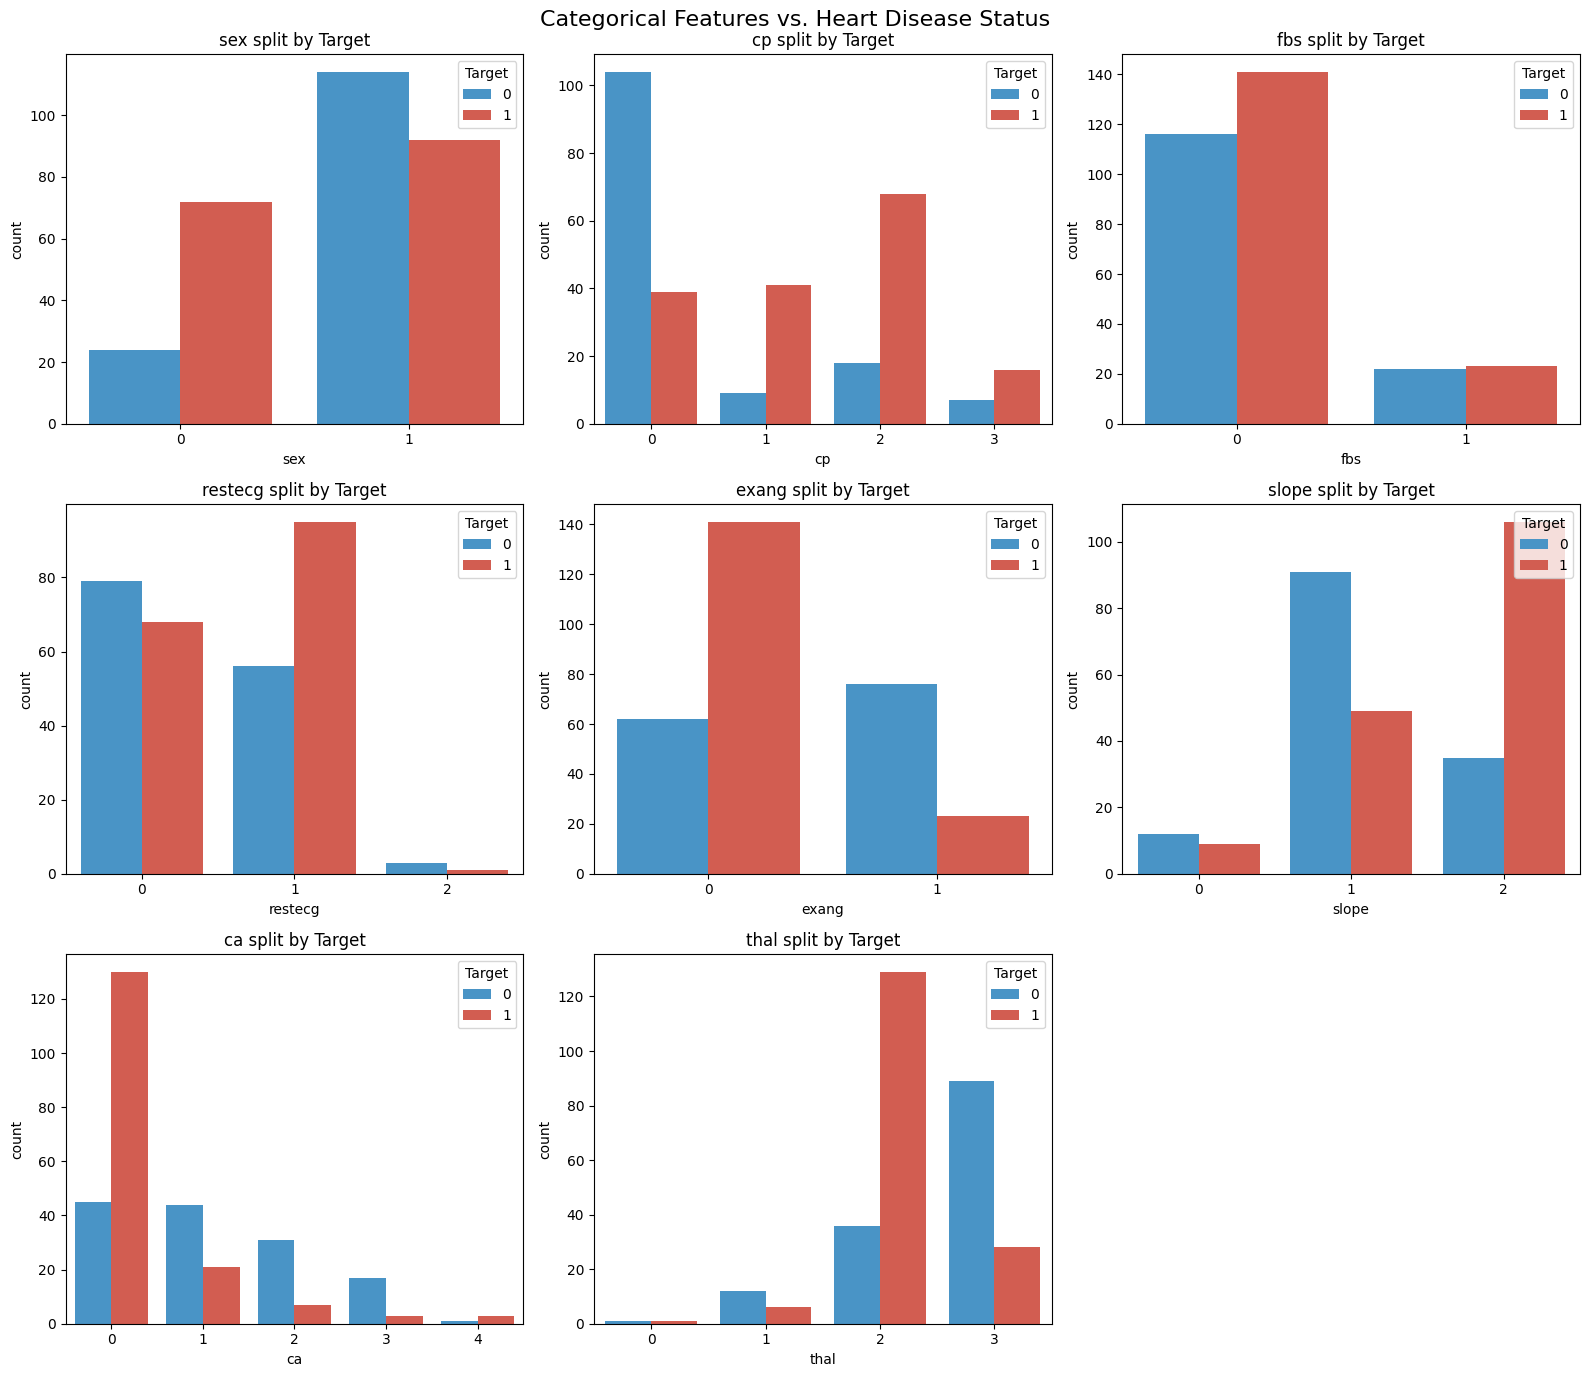

In [4]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 1. Numerical Features vs Target
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
fig.suptitle('Numerical Features vs. Heart Disease Status', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} by Target', fontsize=12)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 2. Categorical Features vs Target
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
fig.suptitle('Categorical Features vs. Heart Disease Status', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} split by Target', fontsize=12)
    axes[i].legend(title='Target', loc='upper right')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Part 4: DATA PREPARATION & MODEL INITIALIZATION

In [5]:
print("--- Initializing Data Splits & Models ---")
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Mandatory for SVM and MLP distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Models (SVM needs probability=True for AUC-ROC)
models = {
    "SVM": SVC(probability=True, random_state=42), 
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Pre-train models on CLEAN data
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
print("All models successfully trained on clean baseline data.")

--- Initializing Data Splits & Models ---


NameError: name 'MLPClassifier' is not defined

# AWGN INJECTION & DEGRADATION EXPERIMENT
This section executes the methodology defined in the paper. We inject Additive White Gaussian Noise (AWGN) incrementally into the test set's numerical features to observe how different machine learning architectures degrade.

In [ ]:
def inject_awgn(X, noise_level):
    """Injects Additive White Gaussian Noise (AWGN) scaled by feature variance."""
    if noise_level == 0.0:
        return X
    np.random.seed(42) # Deterministic noise
    noise = np.random.normal(0, 1, X.shape)
    std_devs = np.std(X, axis=0)
    return X + (noise * std_devs * noise_level)

print("\n--- Executing Degradation Experiment (10% to 50% AWGN) ---")
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
results = {model: {n: {} for n in noise_levels} for model in models}

for name, model in trained_models.items():
    for noise in noise_levels:
        X_test_noisy = inject_awgn(X_test_scaled, noise)
        
        # Predictions & Probabilities
        y_pred = model.predict(X_test_noisy)
        y_prob = model.predict_proba(X_test_noisy)[:, 1] 
        
        # Calculate Comprehensive Metrics
        results[name][noise] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "AUC-ROC": roc_auc_score(y_test, y_prob)
        }
print("Experiment complete. Metrics synthesized.")

## ANALYSIS

In [ ]:
print("\n" + "="*55)
print("1. DETAILED PERFORMANCE METRICS BY NOISE LEVEL")
print("="*55)

for name in models.keys():
    print(f"\n--- Architecture: {name} ---")
    for noise in noise_levels:
        metrics = results[name][noise]
        print(f"Noise {int(noise*100):2d}% | MCC: {metrics['MCC']:.4f} | F1-Score: {metrics['F1-Score']:.4f} | AUC-ROC: {metrics['AUC-ROC']:.4f} | Recall: {metrics['Recall']:.4f}")

print("\n" + "="*55)
print("2. PERFORMANCE DECAY RATE (Δ) AT 50% NOISE")
print("="*55)
for name in models.keys():
    mcc_base = results[name][0.0]["MCC"]
    mcc_max_noise = results[name][0.5]["MCC"]
    decay_rate = ((mcc_base - mcc_max_noise) / mcc_base) * 100
    print(f"{name:<15} | Base MCC: {mcc_base:.4f} | Degraded MCC: {mcc_max_noise:.4f} | Δ = {decay_rate:.2f}% loss")

print("\n" + "="*55)
print("3. CRITICAL BREAKDOWN POINT (BP_crit) ANALYSIS")
print("="*55)
for name in models.keys():
    mcc_baseline = results[name][0.0]["MCC"]
    mcc_all = [results[name][n]["MCC"] for n in noise_levels]
    mcc_std = np.std(mcc_all)
    
    # Identify threshold where performance drop exceeds 2 standard deviations
    bp_crit = next((n for n in noise_levels if (mcc_baseline - results[name][n]["MCC"]) > (2 * mcc_std)), None)
    
    if bp_crit is not None:
        print(f"❌ {name:<13} : Catastrophic collapse detected at {int(bp_crit*100)}% noise.")
    else:
        print(f"✅ {name:<13} : Maintained statistical stability across all noise thresholds.")

## DEGRADATION VISUALIZATIONS & CSV EXPORT

In [ ]:
print("\n--- Generating Academic Visualizations ---")
metrics_to_plot = ["MCC", "F1-Score", "AUC-ROC", "Recall"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Degradation under AWGN', fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    for model_name in models.keys():
        y_values = [results[model_name][n][metric] for n in noise_levels]
        ax.plot(noise_levels, y_values, marker='o', linewidth=2.5, label=model_name)
    
    ax.set_title(f'{metric} Degradation Curve', fontsize=14, fontweight='bold')
    ax.set_xlabel('AWGN Noise Level (%)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(noise_levels)
    ax.set_xticklabels([f"{int(n*100)}%" for n in noise_levels])
    ax.grid(True, linestyle='--', alpha=0.7)
    if i == 0: 
        ax.legend(loc='best', fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

formatted_results = []
for model in models.keys():
    for noise in noise_levels:
        row = {'Model': model, 'Noise (%)': int(noise*100)}
        row.update(results[model][noise])
        formatted_results.append(row)

results_df = pd.DataFrame(formatted_results)
results_df.to_csv("degradation_results_formatted.csv", index=False)
print("\n✅ Results successfully exported to 'degradation_results_formatted.csv'.")